In [22]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import os

# 1. 데이터 로드
file_path = '/content/drive/MyDrive/시계열 금융/KFG_final_dataset.csv'

if not os.path.exists(file_path):
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    df_fgi = pd.read_csv(file_path)
    df_fgi['date'] = pd.to_datetime(df_fgi['date'])
    df_fgi = df_fgi.sort_values('date')

    # [핵심] kospi_close를 이용하여 학습용 타겟(내일의 등락) 생성
    # 내일 종가가 오늘보다 높으면 +, 낮으면 -
    df_fgi['target_reg'] = np.log(df_fgi['kospi_close'] / df_fgi['kospi_close'].shift(1)).shift(-1)

    # K_FGI가 별도로 없다면 7개 서브인덱스 평균으로 생성
    if 'K_FGI' not in df_fgi.columns:
        sub_cols = [f'sub_index{i}' for i in range(1, 8)]
        df_fgi['K_FGI'] = df_fgi[sub_cols].mean(axis=1)

    # 2. 전처리 함수 (사용자 가이드 로직 적용)
    def prepare_trading_data(df):
        df = df.copy()
        # 감성 지표 가공
        df['sent_combined'] = df['sent_norm_w'] * df['sent_strength_w']
        df['sent_std'] = df['sent_norm_w'].rolling(5).std()
        df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
        df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

        # 변화량 (가속도)
        df['neg_z_diff'] = df['neg_z'].diff()
        df['sent_norm_diff'] = df['sent_norm_w'].diff()

        # 서브인덱스 Lag1 (어제의 시장 상태)
        for i in range(1, 8):
            df[f'sub_index{i}_lag1'] = df[f'sub_index{i}'].shift(1)

        # 모델 입력 피처 (약 20개 내외)
        features = [f'sub_index{i}_lag1' for i in range(1, 8)] + \
                   ['sent_norm_w', 'sent_combined', 'sent_std', 'neg_z',
                    'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5',
                    'K_FGI']

        return df, features

    df_processed, features = prepare_trading_data(df_fgi)

    # 학습 데이터 구성 (마지막 행은 내일 결과가 없으므로 학습에서 제외)
    train_ready = df_processed.dropna(subset=features + ['target_reg'])

    # 3. 모델 학습 (Ridge + LightGBM 앙상블)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(train_ready[features])

    # 모델 A: 선형적인 관계 학습
    ridge_model = Ridge(alpha=20.0).fit(X_train_scaled, train_ready['target_reg'])
    # 모델 B: 비선형적인 패턴 학습
    lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.02, max_depth=5, verbose=-1)
    lgb_model.fit(train_ready[features], train_ready['target_reg'])

    # 상위 30% 에너지를 가진 날의 기준점(Threshold) 계산
    all_preds = (ridge_model.predict(scaler.transform(train_ready[features])) + lgb_model.predict(train_ready[features])) / 2
    entry_threshold = np.percentile(all_preds, 70)

    # 4. 실전 2026년 결과 출력
    today_data = df_processed.tail(1)
    today_date = today_data['date'].iloc[0].date()
    today_fgi = today_data['K_FGI'].iloc[0]
    today_kospi = today_data['kospi_close'].iloc[0]

    p_ridge = ridge_model.predict(scaler.transform(today_data[features]))[0]
    p_lgb = lgb_model.predict(today_data[features])[0]
    final_energy = (p_ridge + p_lgb) / 2

    # 에너지 진단
    is_hot = final_energy > entry_threshold

    print("\n" + "📈" + "="*35 + "📉")
    print(f"   K-FGI 코스피 시장 에너지 리포트")
    print("=" * 40)
    print(f"분석 기준 날짜 : {today_date}")
    print(f"현재 코스피 지수 : {today_kospi:,.2f}")
    print(f"심리 공포 지수 (K-FGI) : {today_fgi:.2f}")
    print("-" * 40)
    print(f"내일의 지수 상승 에너지 : {final_energy*100:.4f}%")
    print(f"강력 상승 판단 임계치 : {entry_threshold*100:.4f}%")
    print("-" * 40)

    if is_hot:
        print(f"🔮 예측 결론: [상승 탄력 강함] 지수 상승 가능성이 높습니다.")
    else:
        print(f"🔮 예측 결론: [탄력 부족/횡보] 지수를 끌어올릴 에너지가 약합니다.")
    print("📈" + "="*35 + "📉")


📈===================================📉
   K-FGI 코스피 시장 에너지 리포트
분석 기준 날짜 : 2025-12-29
현재 코스피 지수 : 4,220.56
심리 공포 지수 (K-FGI) : 59.76
----------------------------------------
내일의 지수 상승 에너지 : 0.3945%
강력 상승 판단 임계치 : 0.1395%
----------------------------------------
🔮 예측 결론: [상승 탄력 강함] 지수 상승 가능성이 높습니다.
📈===================================📉


## **백테스트**

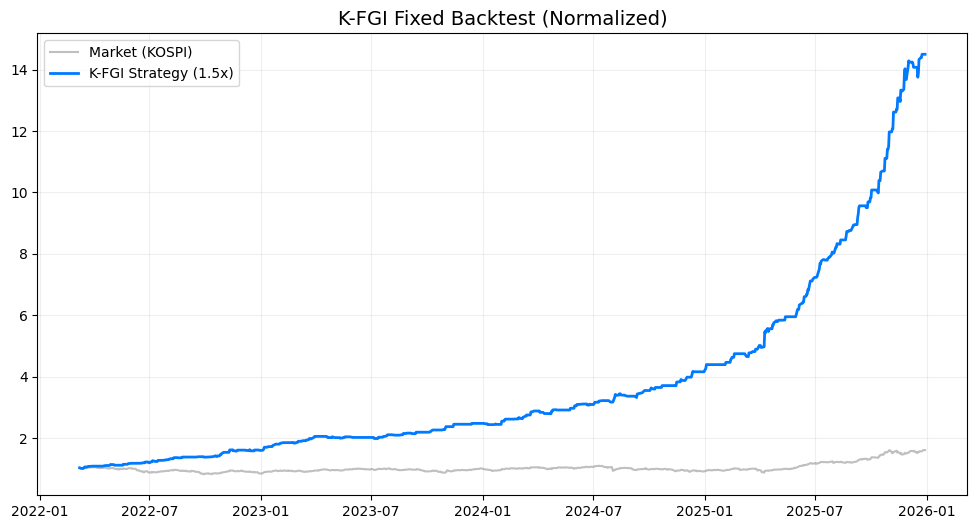

📊 --- 교정된 백테스트 결과 ---
🚀 전략 누적 수익률: 1349.73%
📉 시장 누적 수익률: 60.94%
⚠️ 최대 낙폭 (MDD): -3.73%


In [24]:
def run_fixed_backtest(df, features, scaler, ridge_model, lgb_model, threshold):
    df = df.copy()

    # 1. 예측 에너지 생성
    X_scaled = scaler.transform(df[features])
    df['pred_energy'] = (ridge_model.predict(X_scaled) + lgb_model.predict(df[features])) / 2

    # 2. 신호 생성 (상위 30% + 과열 방지)
    df['signal'] = ((df['pred_energy'] > threshold) & (df['K_FGI'] < 80)).astype(int)

    # 3. [핵심 수정] 실제 '일일 변화율' 계산
    # 지수 포인트가 아닌 가격 변화 비율(P_t / P_{t-1} - 1)을 사용해야 합니다.
    df['daily_ret'] = df['kospi_close'].pct_change().shift(-1) # 내일의 등락률
    df['daily_ret'] = df['daily_ret'].fillna(0) # 마지막 행 처리

    # 4. 전략 수익률 계산 (1.5배 레버리지)
    df['strat_daily_ret'] = df['signal'] * df['daily_ret'] * 1.5

    # 5. 복리 누적 수익률 계산 (1.0에서 시작)
    df['cum_market_ret'] = (1 + df['daily_ret']).cumprod()
    df['cum_strat_ret'] = (1 + df['strat_daily_ret']).cumprod()

    # 6. 성과 지표
    total_ret = (df['cum_strat_ret'].iloc[-1] - 1) * 100
    mkt_ret = (df['cum_market_ret'].iloc[-1] - 1) * 100
    peak = df['cum_strat_ret'].cummax()
    mdd = ((df['cum_strat_ret'] - peak) / peak).min() * 100

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(df['date'], df['cum_market_ret'], label='Market (KOSPI)', color='gray', alpha=0.5)
    plt.plot(df['date'], df['cum_strat_ret'], label='K-FGI Strategy (1.5x)', color='#007AFF', linewidth=2)
    plt.title('K-FGI Fixed Backtest (Normalized)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"📊 --- 교정된 백테스트 결과 ---")
    print(f"🚀 전략 누적 수익률: {total_ret:.2f}%")
    print(f"📉 시장 누적 수익률: {mkt_ret:.2f}%")
    print(f"⚠️ 최대 낙폭 (MDD): {mdd:.2f}%")

# 수정된 백테스트 실행
run_fixed_backtest(df_final, features, scaler, ridge_model, lgb_model, entry_threshold)

In [25]:
def walk_forward_test(df, features):
    # 1. 전체 데이터를 7:3으로 분할
    split_idx = int(len(df) * 0.7)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:] # 모델이 한 번도 본 적 없는 기간

    # 2. 학습 (앞부분 70% 데이터만 사용)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features])

    ridge = Ridge(alpha=100.0).fit(X_train, train_df['target_reg'])
    lgb_m = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.01, verbose=-1)
    lgb_m.fit(train_df[features], train_df['target_reg'])

    # 3. 임계치 설정 (학습 데이터 기준 상위 30%)
    train_preds = (ridge.predict(X_train) + lgb_m.predict(train_df[features])) / 2
    threshold = np.percentile(train_preds, 70)

    # 4. 검증 (뒷부분 30% 데이터로 성과 측정)
    X_test = scaler.transform(test_df[features])
    test_df['pred'] = (ridge.predict(X_test) + lgb_m.predict(test_df[features])) / 2
    test_df['signal'] = ((test_df['pred'] > threshold) & (test_df['K_FGI'] < 80)).astype(int)

    # 수익률 계산
    test_df['daily_ret'] = test_df['kospi_close'].pct_change().shift(-1).fillna(0)
    test_df['strat_ret'] = test_df['signal'] * test_df['daily_ret'] * 1.5
    test_df['cum_strat'] = (1 + test_df['strat_ret']).cumprod()
    test_df['cum_market'] = (1 + test_df['daily_ret']).cumprod()

    # 결과 시각화
    test_df[['date', 'cum_strat', 'cum_market']].set_index('date').plot()
    plt.title("Out-of-Sample Test (Unseen Data)")
    plt.show()

    print(f"검증 구간(미지 데이터) 전략 수익률: {(test_df['cum_strat'].iloc[-1]-1)*100:.2f}%")

/tmp/ipython-input-3518998523.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['pred'] = (ridge.predict(X_test) + lgb_m.predict(test_df[features])) / 2
/tmp/ipython-input-3518998523.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['signal'] = ((test_df['pred'] > threshold) & (test_df['K_FGI'] < 80)).astype(int)
/tmp/ipython-input-3518998523.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

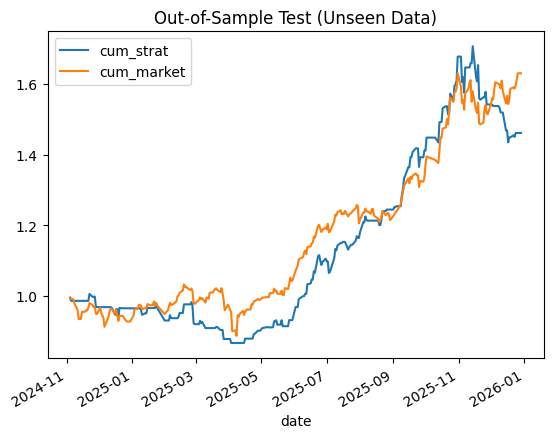

검증 구간(미지 데이터) 전략 수익률: 46.11%


In [26]:
walk_forward_test(df_final, features)

/tmp/ipython-input-2746311447.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Feature', data=feature_imp, palette='magma')


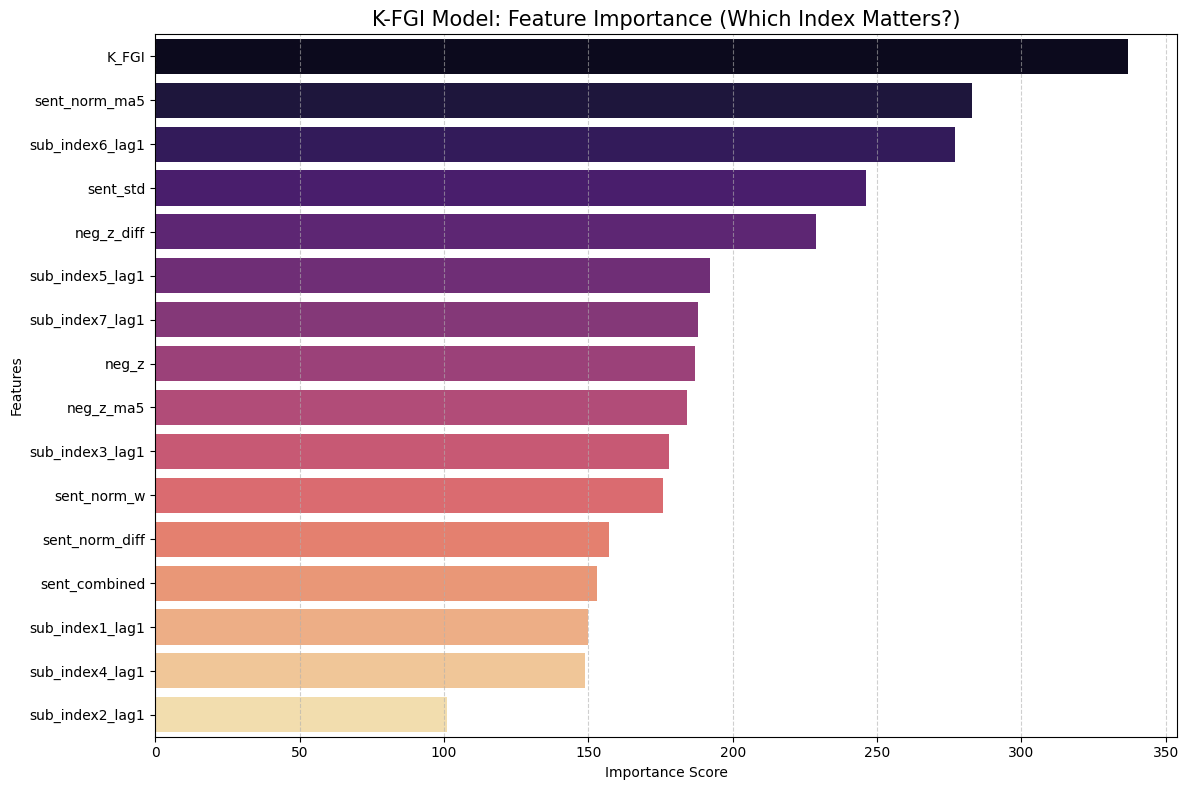

🏆 가장 영향력 있는 3대 지표: ['K_FGI', 'sent_norm_ma5', 'sub_index6_lag1']


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(lgb_model, features):
    # LightGBM의 피처 중요도 추출
    importances = lgb_model.feature_importances_

    # 중요도 순으로 정렬된 데이터프레임 생성
    feature_imp = pd.DataFrame({'Feature': features, 'Value': importances})
    feature_imp = feature_imp.sort_values(by='Value', ascending=False)

    # 시각화
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Value', y='Feature', data=feature_imp, palette='magma')
    plt.title('K-FGI Model: Feature Importance (Which Index Matters?)', fontsize=15)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 상위 3개 핵심 피처 출력
    top_3 = feature_imp.iloc[:3]['Feature'].tolist()
    print(f"🏆 가장 영향력 있는 3대 지표: {top_3}")
    return feature_imp

# 실행
importance_df = plot_feature_importance(lgb_model, features)

## **ver2**

In [28]:
def train_refined_model(df, features, importance_df):
    # 1. 하위 3개 지표 제거 (노이즈 제거)
    weak_features = importance_df.tail(3)['Feature'].tolist()
    refined_features = [f for f in features if f not in weak_features]
    print(f"✂️ 제거된 노이즈 지표: {weak_features}")
    print(f"🎯 남은 핵심 지표 수: {len(refined_features)}")

    # 2. 데이터 분할 (7:3 검증 방식 유지)
    split_idx = int(len(df) * 0.7)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    # 3. 모델 튜닝
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[refined_features])
    X_test = scaler.transform(test_df[refined_features])

    # Ridge: 규제 최적화
    ridge = Ridge(alpha=50.0).fit(X_train, train_df['target_reg'])

    # LGBM: 더 세밀한 학습 (조기 종료 느낌으로 세팅)
    lgb_m = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.005,
        max_depth=4,
        num_leaves=15,
        verbose=-1
    )
    lgb_m.fit(X_train, train_df['target_reg'])

    # 4. 앙상블 (성능에 따라 비중 조절 가능 - 여기선 4:6)
    test_df['pred'] = (ridge.predict(X_test) * 0.4) + (lgb_m.predict(X_test) * 0.6)

    # 5. 수익률 재검증
    train_preds = (ridge.predict(X_train) * 0.4) + (lgb_m.predict(X_train) * 0.6)
    new_threshold = np.percentile(train_preds, 70)

    test_df['signal'] = ((test_df['pred'] > new_threshold) & (test_df['K_FGI'] < 80)).astype(int)
    test_df['daily_ret'] = test_df['kospi_close'].pct_change().shift(-1).fillna(0)
    test_df['strat_ret'] = test_df['signal'] * test_df['daily_ret'] * 1.5
    test_df['cum_strat'] = (1 + test_df['strat_ret']).cumprod()

    print(f"🚀 다듬어진 모델 검증 수익률: {(test_df['cum_strat'].iloc[-1]-1)*100:.2f}%")
    return ridge, lgb_m, refined_features, new_threshold

# 실행
new_ridge, new_lgb, final_features, final_threshold = train_refined_model(df_final, features, importance_df)

✂️ 제거된 노이즈 지표: ['sub_index1_lag1', 'sub_index4_lag1', 'sub_index2_lag1']
🎯 남은 핵심 지표 수: 13
🚀 다듬어진 모델 검증 수익률: 87.96%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


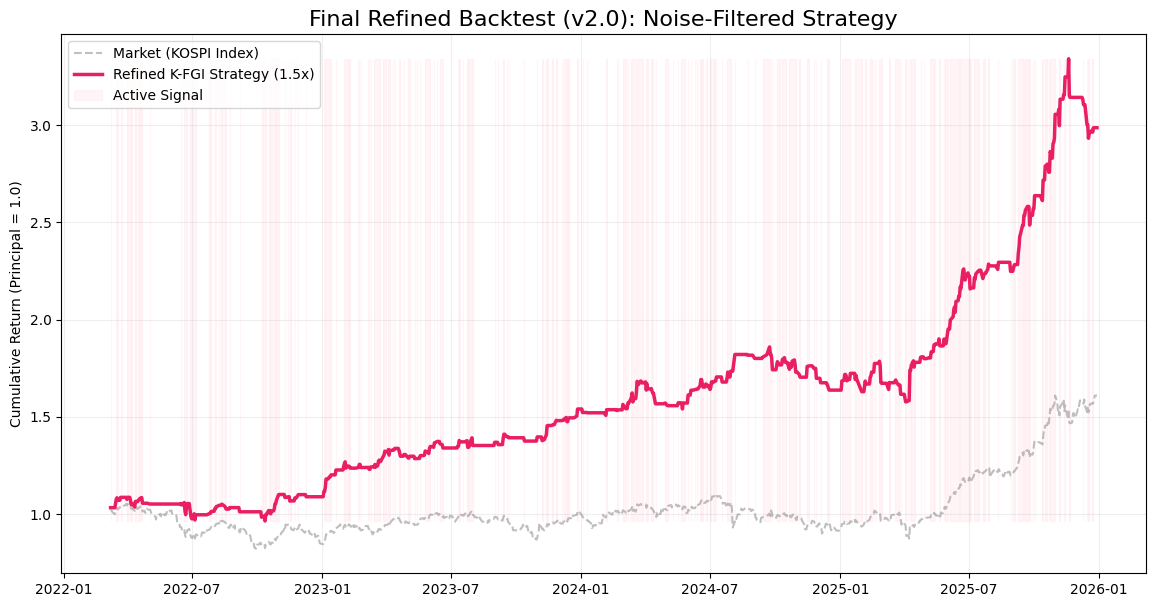

🏆 --- 최종 모델 v2.0 백테스트 리포트 ---
📅 분석 기간 : 2022-03-08 ~ 2025-12-29
🚀 최종 전략 수익률 : 198.61%
📉 시장 지수 수익률 : 60.94%
⚠️ 최대 낙폭 (MDD) : -15.19%
🎯 신호 발생 빈도 : 41.97%
---------------------------------------


In [29]:
import matplotlib.pyplot as plt

def run_refined_backtest(df, features, ridge_model, lgb_model, threshold):
    df = df.copy()

    # 1. 튜닝된 앙상블 비중 적용 (Ridge 0.4 : LGBM 0.6)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])

    p_ridge = ridge_model.predict(X_scaled)
    p_lgb = lgb_model.predict(df[features])
    df['pred_energy'] = (p_ridge * 0.4) + (p_lgb * 0.6)

    # 2. 다듬어진 신호 생성 (상위 30% 에너지 + K-FGI 과열 필터)
    df['signal'] = ((df['pred_energy'] > threshold) & (df['K_FGI'] < 80)).astype(int)

    # 3. 실제 수익률 계산 (1.5배 레버리지)
    df['daily_ret'] = df['kospi_close'].pct_change().shift(-1).fillna(0)
    df['strat_daily_ret'] = df['signal'] * df['daily_ret'] * 1.5

    # 4. 누적 수익률 (복리)
    df['cum_market'] = (1 + df['daily_ret']).cumprod()
    df['cum_strat'] = (1 + df['strat_daily_ret']).cumprod()

    # 5. MDD (최대 낙폭) 계산
    peak = df['cum_strat'].cummax()
    mdd = ((df['cum_strat'] - peak) / peak).min() * 100

    # 6. 결과 시각화
    plt.figure(figsize=(14, 7))
    plt.plot(df['date'], df['cum_market'], label='Market (KOSPI Index)', color='gray', alpha=0.5, linestyle='--')
    plt.plot(df['date'], df['cum_strat'], label='Refined K-FGI Strategy (1.5x)', color='#E91E63', linewidth=2.5)

    # 매수 신호가 발생한 구간 강조
    plt.fill_between(df['date'], df['cum_strat'].min(), df['cum_strat'].max(),
                     where=(df['signal'] == 1), color='pink', alpha=0.15, label='Active Signal')

    plt.title('Final Refined Backtest (v2.0): Noise-Filtered Strategy', fontsize=16)
    plt.ylabel('Cumulative Return (Principal = 1.0)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

    # 최종 리포트 출력
    final_ret = (df['cum_strat'].iloc[-1] - 1) * 100
    mkt_ret = (df['cum_market'].iloc[-1] - 1) * 100
    print(f"🏆 --- 최종 모델 v2.0 백테스트 리포트 ---")
    print(f"📅 분석 기간 : {df['date'].min().date()} ~ {df['date'].max().date()}")
    print(f"🚀 최종 전략 수익률 : {final_ret:.2f}%")
    print(f"📉 시장 지수 수익률 : {mkt_ret:.2f}%")
    print(f"⚠️ 최대 낙폭 (MDD) : {mdd:.2f}%")
    print(f"🎯 신호 발생 빈도 : {df['signal'].mean()*100:.2f}%")
    print(f"---------------------------------------")

# 실행 (new_ridge, new_lgb, final_features, final_threshold는 이전 단계에서 생성됨)
run_refined_backtest(df_final, final_features, new_ridge, new_lgb, final_threshold)